In [2]:
import os
import sys
sys.path.insert(0, '/home/aiscuser/verl')
import torch
from verl.third_party.sglang.entrypoint import CustomEngine
from verl.utils.dataset.rl_dataset import RLHFDataset, collate_fn
os.environ["SGLANG_BLOCK_NONZERO_RANK_CHILDREN"] = "0"
from transformers import AutoTokenizer, AutoProcessor
from uuid import uuid4

/opt/conda/envs/ptca/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-09 17:35:29,426	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


INFO 05-09 17:35:30 __init__.py:190] Automatically detected platform rocm.
WARNING 05-09 17:35:30 rocm.py:33] `fork` method is not supported by ROCm. VLLM_WORKER_MULTIPROC_METHOD is overridden to `spawn` instead.


In [3]:
engine = CustomEngine(
    model_path='meta-llama/Llama-3.1-8B-Instruct',
    dtype=torch.bfloat16,
    mem_fraction_static=0.4,
    base_gpu_id=0,
    gpu_id_step=1,
    max_running_requests=128,
    cuda_graph_max_bs=128,
    tp_size=4,
    enable_mixed_chunk=True,
    node_rank=0,
    stream_interval=256,
    nnodes=1,
    enable_torch_compile=False,
)


INFO 05-09 17:35:39 __init__.py:190] Automatically detected platform rocm.
INFO 05-09 17:35:39 __init__.py:190] Automatically detected platform rocm.
INFO 05-09 17:35:39 __init__.py:190] Automatically detected platform rocm.
INFO 05-09 17:35:39 __init__.py:190] Automatically detected platform rocm.
INFO 05-09 17:35:39 __init__.py:190] Automatically detected platform rocm.
node-0:344585:344585 [0] NCCL INFO Bootstrap : Using eth0:100.64.55.73<0>
node-0:344585:344585 [0] NCCL INFO NET/Plugin : dlerror=librccl-net.so: cannot open shared object file: No such file or directory No plugin found (librccl-net.so), using internal implementation
node-0:344585:344585 [0] NCCL INFO Kernel version: 5.15.0-1073-azure
node-0:344587:344587 [1] NCCL INFO ROCr version 1.14
node-0:344587:344587 [1] NCCL INFO Dmabuf feature disabled without NCCL_DMABUF_ENABLE=1
node-0:344589:344589 [3] NCCL INFO ROCr version 1.14
node-0:344589:344589 [3] NCCL INFO Dmabuf feature disabled without NCCL_DMABUF_ENABLE=1
node-0

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:00<00:00,  8.44it/s]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:00<00:00,  2.90it/s]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:01<00:00,  2.20it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:01<00:00,  1.91it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:01<00:00,  2.18it/s]

100%|██████████| 19/19 [00:09<00:00,  2.05it/s]


In [9]:
import asyncio
from typing import List, Dict, Optional, Union
from sglang.srt.managers.io_struct import GenerateReqInput, AbortReq
from sglang.srt.entrypoints.verl_engine import VerlEngine as VerlEngineBase
from sglang.srt.entrypoints.verl_engine import _preprocess_tensor_for_update_weights
from sglang.srt.server import Engine
from sglang.srt.utils import MultiprocessingSerializer, broadcast_pyobj
from sglang.srt.model_executor.model_runner import LocalSerializedTensor
import time

async def get_first_value(async_gen):
    return await async_gen.__anext__()

async def get_first_n_results(self, tasks, num_returns):
    outputs = {}
    completed_oids = []
    completed_rids = []
    all_tasks = [task for task_dict in tasks.values() for task in task_dict.values()]
    for oid in tasks.keys():
        outputs[oid] = {}

    queue_stat = []
    for task in asyncio.as_completed(all_tasks):
        result = await task
        rid = result['meta_info']['id']
        oid = rid.split('_nid')[0]
        outputs[oid][rid] = result
        completed_rids.append(rid)
        tasks[oid].pop(rid)
        queue_stat.append((time.time(), num_returns - len(completed_rids)))
        if len(tasks[oid].keys()) == 0:
            completed_oids.append(oid)
            tasks.pop(oid)
        if len(completed_oids) >= num_returns:
            break

    for oid, task_dict in tasks.items():
        for rid in task_dict.keys():
            self.tokenizer_manager.abort_request(rid)



    # Wait for idle
    while True:
        # print(f'waiting for idle')
        internal_state = await self.tokenizer_manager.get_internal_state()
        if internal_state['is_idle']:
            # print(f'idle')
            break
    
    # Scavenge incomplete results
    incomplete_tasks = [task for task_dict in tasks.values() for task in task_dict.values()]



    await asyncio.sleep(1)
    for task in incomplete_tasks:
        if task.done():
            result = await task
            incomplete_tasks.remove(task)
            rid = result['meta_info']['id']
            oid = rid.split('_nid')[0]
            outputs[oid][rid] = result
            finish_reason = result['meta_info'].get('finish_reason', {type: ''})
            # to_delete_rids.remove(rid)
            if finish_reason['type'] != 'abort':
                completed_rids.append(rid)
                tasks[oid].pop(rid)
                if len(tasks[oid].keys()) == 0:
                    completed_oids.append(oid)
                    tasks.pop(oid)
        else:
            task.cancel()

    partial_outputs = self.gather_partial_outputs()

    self.tokenizer_manager.clear_queue()
    for output in partial_outputs:
        rid = output['meta_info']['id']
        oid = rid.split('_nid')[0]
        outputs[oid][rid] = output

    return outputs, queue_stat

def custom_generate(
    self,
    # The input prompt. It can be a single prompt or a batch of prompts.
    prompt: Optional[List[str]] = None,
    sampling_params: Optional[Union[List[Dict], Dict]] = None,
    # The token ids for text; one can either specify text or input_ids.
    input_ids: Optional[Union[List[List[int]], List[int]]] = None,
    # The image input. It can be a file name, a url, or base64 encoded string.
    # See also python/sglang/srt/utils.py:load_image.
    image_data: Optional[Union[List[str], str]] = None,
    return_logprob: Optional[Union[List[bool], bool]] = False,
    logprob_start_len: Optional[Union[List[int], int]] = None,
    top_logprobs_num: Optional[Union[List[int], int]] = None,
    token_ids_logprob: Optional[Union[List[List[int]], List[int]]] = None,
    lora_path: Optional[List[Optional[str]]] = None,
    custom_logit_processor: Optional[Union[List[str], str]] = None,
    stream: bool = False,
    rid: Optional[Union[List[str], str]] = None,
    num_returns: Optional[int] = None,
) -> Union[Dict]:
    if prompt is not None:
        batch_size = len(prompt)
    if input_ids is not None:
        batch_size = len(input_ids)
    loop = asyncio.get_event_loop()
    
    n = sampling_params.get("n", 1) if sampling_params is not None else 1
    sampling_params_ = sampling_params.copy()
    sampling_params_['n'] = 1
    assert num_returns is not None, "num_returns should be provided"
    assert rid is not None, "rid should be provided"

    original_rids = list(set([rid.split('_nid')[0] for rid in rid]))
    all_rids = rid


    objs = {}
    tasks = {}
    for oid in original_rids:
        objs[oid] = {}
        tasks[oid] = {}
    for i, rid in enumerate(all_rids):
        oid = rid.split('_nid')[0]
        tmp_sampling_params = sampling_params_.copy()
        max_new_tokens = sampling_params_.get('max_new_tokens', 16*1024)
        max_length = 18 * 1024
        context_length = len(input_ids[i])
        max_new_tokens = min(max_new_tokens, max_length - context_length)
        max_new_tokens = max(max_new_tokens, 1)
        tmp_sampling_params['max_new_tokens'] = max_new_tokens
        objs[oid][rid] = GenerateReqInput(
            text=None,
            input_ids=input_ids[i],
            sampling_params=tmp_sampling_params,
            image_data=None,
            return_logprob=return_logprob,
            logprob_start_len=logprob_start_len,
            top_logprobs_num=top_logprobs_num,
            token_ids_logprob=token_ids_logprob,
            lora_path=lora_path,
            custom_logit_processor=custom_logit_processor,
            stream=False,
            rid=rid,
        )
        generator = self.tokenizer_manager.generate_request(objs[oid][rid], None)
        task = loop.create_task(get_first_value(generator))
        tasks[oid][rid] = task



    outputs, queue_stat = loop.run_until_complete(self.get_first_n_results(tasks, num_returns))

    return outputs, queue_stat

engine.custom_generate = custom_generate.__get__(engine, CustomEngine)
engine.get_first_n_results = get_first_n_results.__get__(engine, CustomEngine)

In [5]:
tokenizer = AutoTokenizer.from_pretrained('meta-llama/Llama-3.1-8B-Instruct')
processor = AutoProcessor.from_pretrained('meta-llama/Llama-3.1-8B-Instruct')
dataset = RLHFDataset(
    parquet_files=['/home/aiscuser/data/kk/train.parquet'],
    tokenizer=tokenizer,
    processor=processor,
    prompt_key='prompt',
    max_prompt_length=2048,
    filter_prompts=True,
    return_raw_chat=False,
    truncation='error',
    filter_overlong_prompts=False
    )

dataset len: 4500


In [10]:
input_ids = []
sampling_params = {
        'top_k': -1,
        'top_p': 1,
        'temperature': 0.8,
        'max_new_tokens': 16 * 1024,
        'n': 1,
        'min_new_tokens': 1,
        'skip_special_tokens': True,
    }
rids = []
for i in range(0, 256):
    data = dataset[i]
    input_ids.append(data['input_ids'].tolist())
    rids.append(f'req{str(uuid4().hex)[:8]}_nid{str(uuid4().hex)[:8]}')


In [11]:
output, queue_stat = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params,
    rid=rids,
    num_returns=256,
    return_logprob=True,
)

Clear queue
Clear queue
Clear queue
Clear queue


In [12]:
queue_stat

[(1746813036.6967626, 255),
 (1746813036.6967716, 254),
 (1746813036.719551, 253),
 (1746813036.71956, 252),
 (1746813036.7195654, 251),
 (1746813036.7835598, 250),
 (1746813036.7835684, 249),
 (1746813036.7835732, 248),
 (1746813036.7835774, 247),
 (1746813036.7835827, 246),
 (1746813036.7835872, 245),
 (1746813036.7835915, 244),
 (1746813036.8292122, 243),
 (1746813037.026505, 242),
 (1746813037.0467782, 241),
 (1746813037.106237, 240),
 (1746813037.106244, 239),
 (1746813037.1062536, 238),
 (1746813037.1473103, 237),
 (1746813037.248592, 236),
 (1746813037.2883904, 235),
 (1746813037.4715393, 234),
 (1746813037.886513, 233),
 (1746813037.9915977, 232),
 (1746813038.2195487, 231),
 (1746813038.2620528, 230),
 (1746813038.6127295, 229),
 (1746813038.6968465, 228),
 (1746813038.8385382, 227),
 (1746813039.21286, 226),
 (1746813039.2128668, 225),
 (1746813039.2128706, 224),
 (1746813039.212874, 223),
 (1746813039.2128773, 222),
 (1746813039.2128804, 221),
 (1746813039.33565, 220),
 (174

In [17]:
running_requests

[128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 128,
 127,
 126,
 125,
 124,
 123,
 122,
 121,
 120,
 119,
 118,
 117,
 116,
 115,
 114,
 113,
 112,
 111,
 110,
 109,
 108,
 107,
 106,
 105,
 104,
 103,
 102,
 101,
 100,
 99,
 98,
 97,
 96,
 95,
 94,
 93,
 92,
 91,
 90,
 89,
 88,
 87,

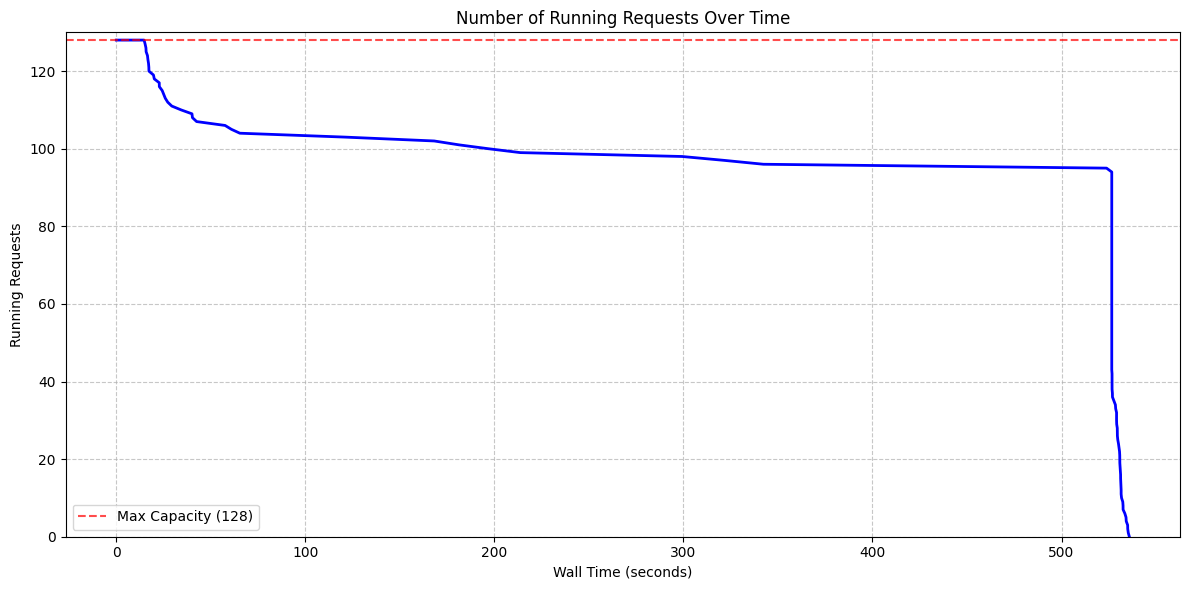

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract timestamps and remaining requests from queue_stat
timestamps = [stat[0] for stat in queue_stat]
remaining_requests = [stat[1] for stat in queue_stat]

# Convert to relative time (starting from 0)
start_time = timestamps[0]
relative_times = [t - start_time for t in timestamps]

# Calculate running requests (128 + remaining requests beyond 128)
# If remaining requests > 128, then we're at max capacity (128)
# Otherwise, we calculate 256 - remaining to get current running
running_requests = []
total_requests = 256

for remaining in remaining_requests:
    if remaining > 128:
        # We're at max capacity (128 running)
        running_requests.append(128)
    else:
        # Calculate actual running requests
        running_requests.append(remaining)

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(relative_times, running_requests, 'b-', linewidth=2)
plt.xlabel('Wall Time (seconds)')
plt.ylabel('Running Requests')
plt.title('Number of Running Requests Over Time')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 130)  # Set y-axis limits with a little headroom above 128

# Add horizontal line at max capacity (128)
plt.axhline(y=128, color='r', linestyle='--', alpha=0.7, label='Max Capacity (128)')

plt.legend()
plt.tight_layout()
plt.show()

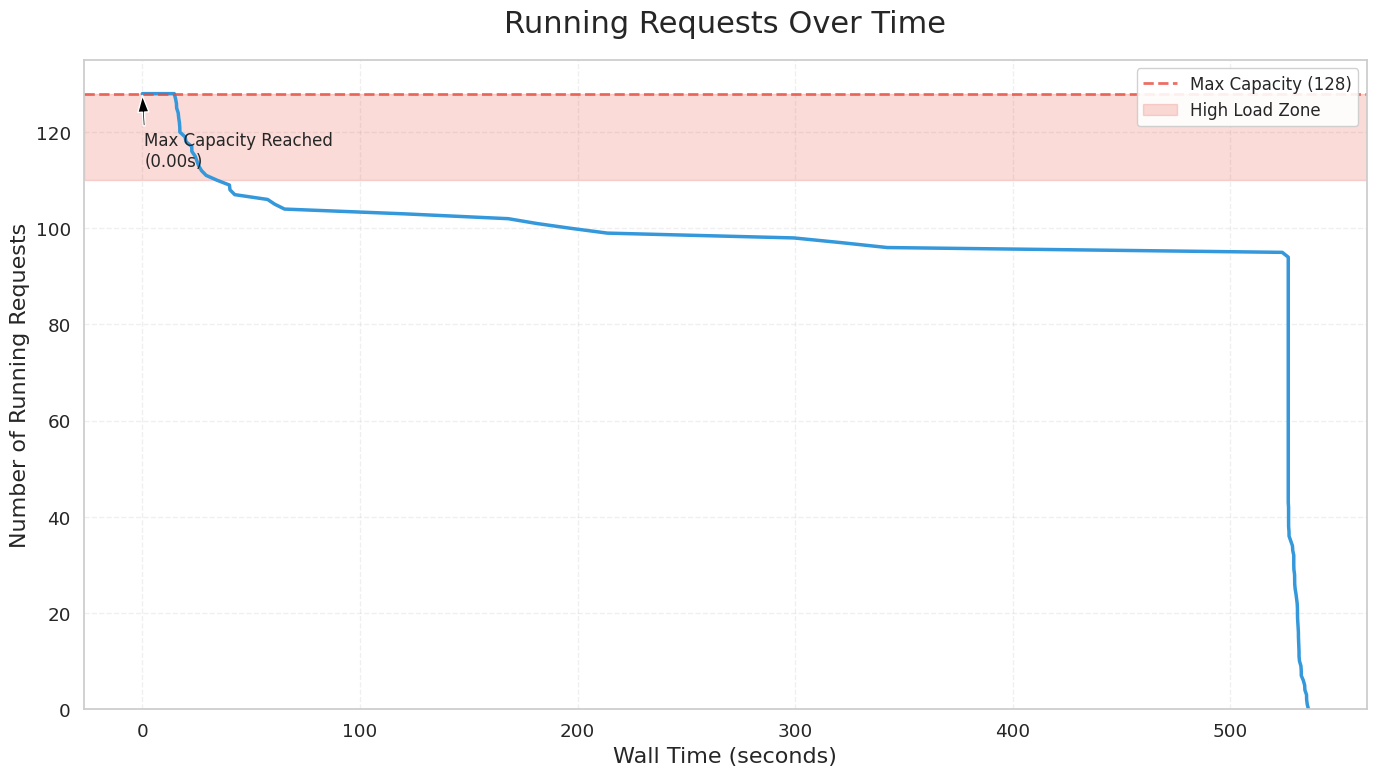

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set the Seaborn style and context
sns.set(style="whitegrid")
sns.set_context("notebook", font_scale=1.2)

# Create a DataFrame for better plotting with Seaborn
data = pd.DataFrame({
    'Wall Time (seconds)': relative_times,
    'Running Requests': running_requests
})

# Create the enhanced plot
plt.figure(figsize=(14, 8))
ax = sns.lineplot(
    data=data, 
    x='Wall Time (seconds)', 
    y='Running Requests',
    linewidth=2.5,
    color='#3498db'
)

# Add a horizontal line at max capacity
plt.axhline(y=128, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.8, label='Max Capacity (128)')

# Add shaded region to represent high load zone
plt.axhspan(110, 128, alpha=0.2, color='#e74c3c', label='High Load Zone')

# Enhance the plot appearance
plt.title('Running Requests Over Time', fontsize=22, pad=20)
plt.ylabel('Number of Running Requests', fontsize=16)
plt.xlabel('Wall Time (seconds)', fontsize=16)
plt.ylim(0, 135)

# Add annotations for key points
max_point_idx = np.argmax(running_requests)
max_point_x = relative_times[max_point_idx]
max_point_y = running_requests[max_point_idx]

if max_point_y == 128:
    # Find the first point where we hit max capacity
    max_indices = [i for i, val in enumerate(running_requests) if val == 128]
    if max_indices:
        max_point_idx = max_indices[0]
        max_point_x = relative_times[max_point_idx]
        plt.annotate(f'Max Capacity Reached\n({max_point_x:.2f}s)',
                    xy=(max_point_x, max_point_y),
                    xytext=(max_point_x + 1, max_point_y - 15),
                    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                    fontsize=12)

# Customize the legend
plt.legend(loc='upper right', frameon=True, framealpha=0.9, fontsize=12)

# Add grid but make it subtle
plt.grid(True, linestyle='--', alpha=0.3)

# Improve layout
plt.tight_layout()

# Show the plot
plt.show()